## 2D Forming Connections 

Contains code of plots like probability distributions or desired kernels. 

import utils

In [1]:
import sys
import os
sys.path.append(os.path.abspath('..')) 
from lib.utils import *

1. Plot Von-Mises Probability Scaling

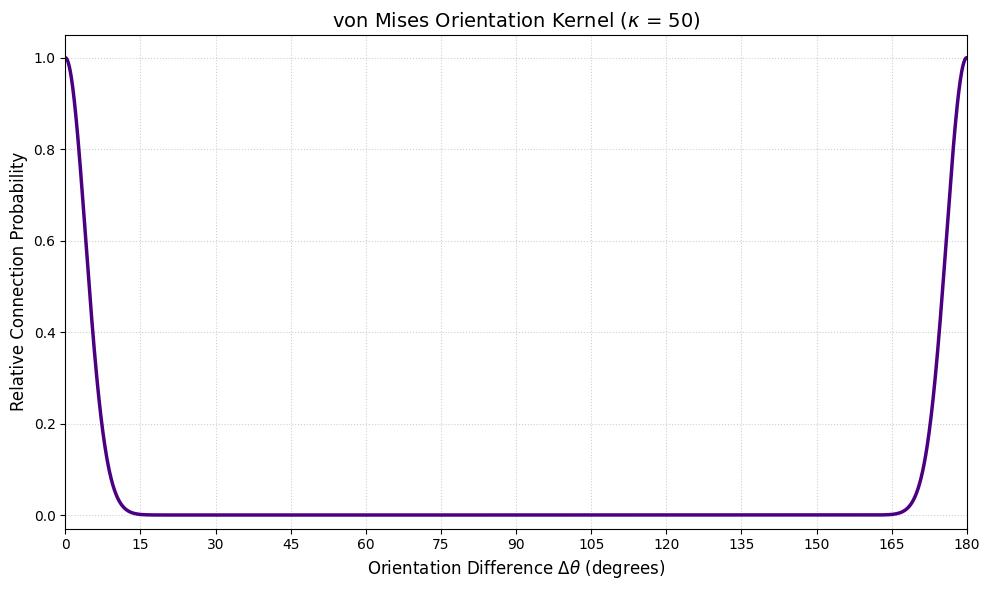

In [2]:
#############################
#   von Mises Orientation   #
#############################

kappa = 50

dtheta_deg = np.linspace(0, 180, 1801)
vm = np.exp(kappa * (np.cos(2 * np.radians(dtheta_deg)) - 1.0))

plt.figure(figsize=(10, 6))
plt.plot(dtheta_deg, vm, linestyle='-', color='indigo', linewidth=2.5)

plt.title(rf'von Mises Orientation Kernel ($\kappa$ = {kappa})', fontsize=14)
plt.xlabel(r'Orientation Difference $\Delta\theta$ (degrees)', fontsize=12)
plt.ylabel('Relative Connection Probability', fontsize=12)
plt.xticks(np.arange(0, 181, 15))
plt.xlim(0, 180)
plt.ylim(-0.03, 1.05)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

2. 2D Gaussian Filter

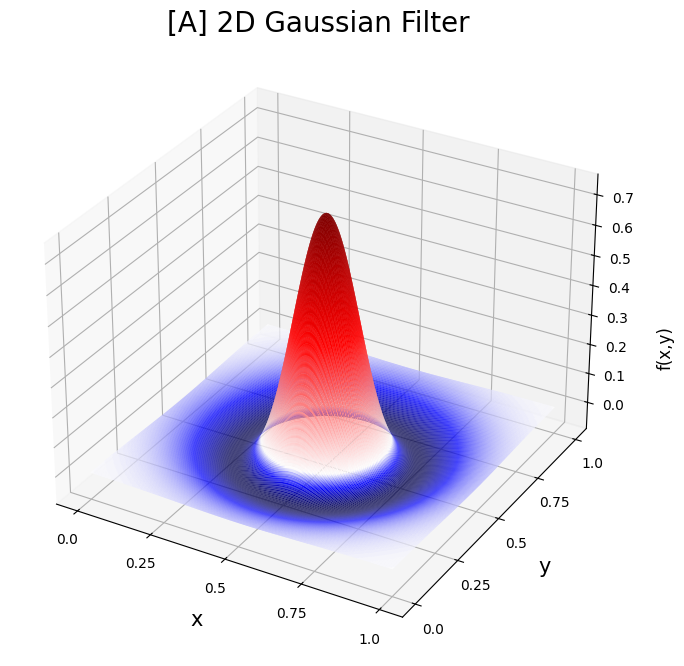

In [3]:
sigma_e = 1.0   
sigma_i = 2.0   

x = np.linspace(-5, 5, 300)
y = np.linspace(-5, 5, 300)
X, Y = np.meshgrid(x, y)

R2 = X**2 + Y**2
Z = (1/sigma_e**2) * np.exp(-R2 / (2*sigma_e**2)) \
  - (1/sigma_i**2) * np.exp(-R2 / (2*sigma_i**2))

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

norm = TwoSlopeNorm(vmin=Z.min(), vcenter=0, vmax=Z.max())
surf = ax.plot_surface(
    X, Y, Z,
    cmap='seismic', norm=norm,
    edgecolor='none',
    rcount=300, ccount=300,
    antialiased=True,
)

ticks = np.linspace(-5, 5, 5)
tick_labels = ['0.0', '0.25', '0.5', '0.75', '1.0']
ax.set_xticks(ticks)
ax.set_xticklabels(tick_labels)
ax.set_yticks(ticks)
ax.set_yticklabels(tick_labels)

ax.set_title('[A] 2D Gaussian Filter', fontsize=20)
ax.set_xlabel('x', labelpad=10, fontsize=15)
ax.set_ylabel('y', labelpad=10, fontsize=15)

ax.text2D(1.05, 0.5, 'f(x,y)', transform=ax.transAxes, rotation=90, 
          verticalalignment='center', horizontalalignment='left', fontsize=12)

fig.subplots_adjust(left=0.05, right=0.85)

plt.show()

3. 2D Gabor Filter

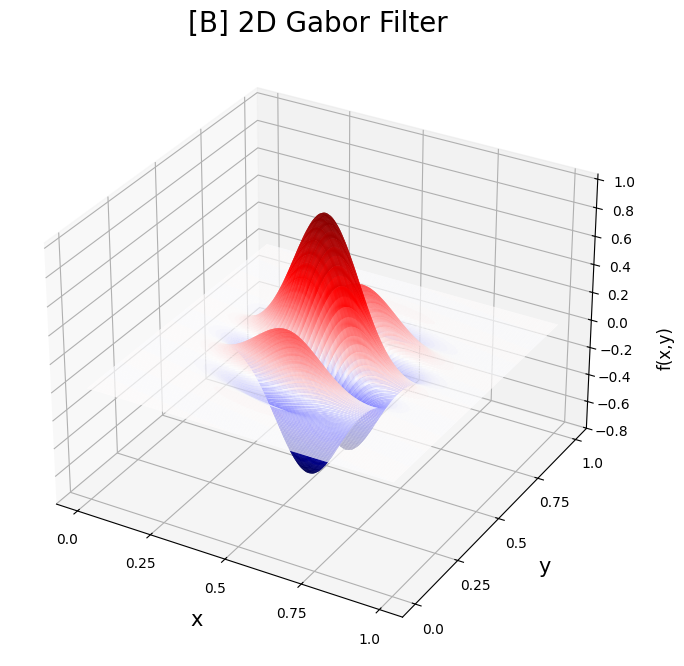

In [4]:
sigma = 1.2        
theta = np.pi/2.25       
lam = 1.8          
gamma = 1.0        
psi = 0.0          

x = np.linspace(-5, 5, 300)
y = np.linspace(-5, 5, 300)
X, Y = np.meshgrid(x, y)

X_prime = X * np.cos(theta) + Y * np.sin(theta)
Y_prime = -X * np.sin(theta) + Y * np.cos(theta)

envelope = np.exp(-(X_prime**2 + (gamma**2 * Y_prime**2)) / (2 * sigma**2))
carrier = np.cos(2 * np.pi * (X_prime / lam) + psi)

Z = envelope * carrier

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

norm = TwoSlopeNorm(vmin=Z.min(), vcenter=0, vmax=Z.max())
surf = ax.plot_surface(
    X, Y, Z,
    cmap='seismic', norm=norm, 
    edgecolor='none',
    rcount=300, ccount=300,
    antialiased=True,
)

ticks = np.linspace(-5, 5, 5)
tick_labels = ['0.0', '0.25', '0.5', '0.75', '1.0']
ax.set_xticks(ticks)
ax.set_xticklabels(tick_labels)
ax.set_yticks(ticks)
ax.set_yticklabels(tick_labels)

ax.set_title('[B] 2D Gabor Filter', fontsize=20)
ax.set_xlabel('x', labelpad=10, fontsize=15)
ax.set_ylabel('y', labelpad=10, fontsize=15)

ax.text2D(1.05, 0.5, 'f(x,y)', transform=ax.transAxes, rotation=90, 
          verticalalignment='center', horizontalalignment='left', fontsize=12)

fig.subplots_adjust(left=0.05, right=0.85)

plt.show()